# ⚡ Zero-Shot Short-Term Load Forecasting with EnergyTTM

**EnergyTTM** is a lightweight time-series foundation model pretrained on **1.26 billion hourly electricity consumption readings** from **76,000+ buildings**. In this notebook, we evaluate its **zero-shot forecasting** capability—making accurate predictions on previously unseen buildings **without any task-specific fine-tuning**.

<a target="_blank" href="https://colab.research.google.com/github/energyfms/notebooks/blob/main/energy_ttm_zeroshot.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### 📈 What is Short-Term Load Forecasting (STLF)?

**Short-Term Load Forecasting (STLF)** aims to predict future electricity demand over the next few hours or days using historical consumption patterns. Accurate STLF is essential for:

- ⚡ Power grid operation and balancing
- 🔋 Demand response and energy optimization
- 🏢 Building energy management systems
- 🌱 Reducing operational costs and improving sustainability

This notebook focuses on the common **day-ahead forecasting** setting, where the model predicts the **next 24 hours** of electricity demand from the **previous 7 days** of observations.

---

### 📝 Experiment Setup

In this notebook, you will:

- 📦 Load a pretrained **EnergyTTM** checkpoint
- 🏢 Prepare building-level energy consumption time series
- 📊 Generate **24-hour forecasts** using **zero-shot inference**
- 📉 Compare predictions against ground truth
- 📏 Evaluate forecasting performance using standard metrics

No model training or fine-tuning is required.



| Setting | Value |
|---------|-------|
| 🧠 Model | **EnergyTTM (Pretrained)** |
| 🔒 Inference | Zero-Shot (No Fine-Tuning) |
| 📅 Context Length | **168 hours** (Previous 7 days) |
| 🔮 Forecast Horizon | **24 hours** (Next day) |
| 🏢 Evaluation | Previously unseen buildings |


---

### 📊 Evaluation Metrics

The forecasts are evaluated using commonly used regression metrics:

- **MAE** – Mean Absolute Error
- **RMSE** – Root Mean Squared Error

---

### 🎯 Goal

The objective is to evaluate how well a pretrained **EnergyTTM** model generalizes to **new buildings** in a completely **zero-shot** setting. Strong performance demonstrates the effectiveness of foundation models for real-world energy forecasting without requiring building-specific training.



### Install Granite-TSFM dependencies

In [ ]:
! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

In [1]:
import os
import random 
import math 
import tempfile 
import torch 
import pickle 
import logging 
import warnings
import json
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np 
import pandas as pd
from transformers import  set_seed
from torch.utils.data import ConcatDataset, Dataset, DataLoader
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/energyfms/notebooks/refs/heads/main/Dataset/Forecasting/sample_building_ashrae.csv")

In [5]:
df.head()

,timestamp,meter_reading
0,2016-01-01 00:00:00,3.4
1,2016-01-01 01:00:00,1.8
2,2016-01-01 02:00:00,2.2
3,2016-01-01 03:00:00,2.2
4,2016-01-01 04:00:00,2.3


In [6]:

# Set index
df.set_index("timestamp", inplace=True)
df.index = pd.to_datetime(df.index)
# Ensure numeric
df["meter_reading"] = pd.to_numeric(df["meter_reading"], errors="coerce")


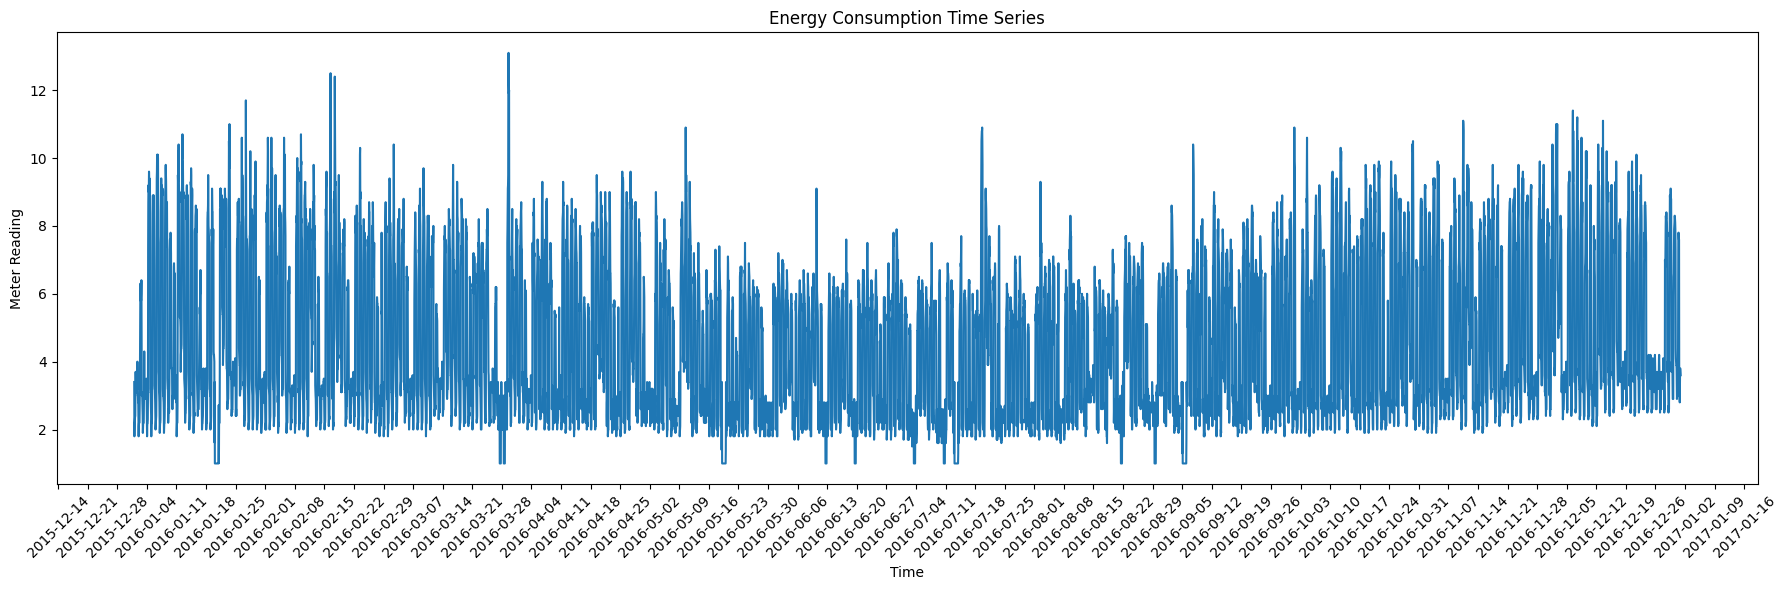

In [7]:
import matplotlib.dates as mdates

plt.figure(figsize=(18, 6))
plt.plot(df.index, df["meter_reading"])

ax = plt.gca()

# Major ticks every week (Monday)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.title("Energy Consumption Time Series")
plt.xlabel("Time")
plt.ylabel("Meter Reading")
plt.tight_layout()
plt.show()

In [8]:
print(df.isna().sum())
df.describe()

meter_reading    0
dtype: int64


,meter_reading
count,8784.000000
mean,4.565478
std,2.436957
min,1.000000
25%,2.500000
50%,3.400000
75%,6.600000
max,13.100000


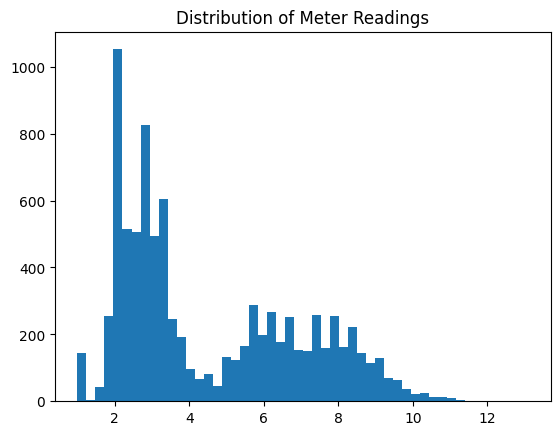

In [9]:
plt.figure()
plt.hist(df["meter_reading"], bins=50)
plt.title("Distribution of Meter Readings")
plt.show()

In [10]:
split_idx = int(len(df) * 0.75)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 6588
Test size: 2196


## MLP Baseline Model

#### Model Definition

In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        seq_len=168,
        pred_len=24,
        hidden_dim=128,
    ):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, pred_len),
        )

    def forward(self, x):
        """
        x : (B, 168)
        returns : (B, 24)
        """
        return self.model(x)

#### Custom Dataset

In [12]:

class ForecastDataset(Dataset):
    def __init__(self, series, context_len=168, pred_len=24):
        self.series = np.asarray(series, dtype=np.float32)
        self.context_len = context_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.series) - self.context_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.context_len]
        y = self.series[
            idx+self.context_len:
            idx+self.context_len+self.pred_len
        ]

        return (
            torch.tensor(x),
            torch.tensor(y),
        )

#### Intialise Model and dataset

In [13]:
from torch.utils.data import DataLoader

train_dataset = ForecastDataset(
    train["meter_reading"].values,
    context_len=168,
    pred_len=24,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

model = MLP(
    seq_len=168,
    pred_len=24,
    hidden_dim=128
).to('cuda')

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

#### Training MLP for Short-term Load Forecasting

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_mlp = MLP(
    seq_len=168,
    pred_len=24,
    hidden_dim=128
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_mlp.parameters(),
    lr=1e-3,
)

epochs = 25

for epoch in range(epochs):

    model_mlp.train()

    running_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss = {running_loss/len(train_loader):.6f}"
    )

Epoch 01 | Loss = 27.486515
Epoch 02 | Loss = 27.486546
Epoch 03 | Loss = 27.487623
Epoch 04 | Loss = 27.486022
Epoch 05 | Loss = 27.486770
Epoch 06 | Loss = 27.487803
Epoch 07 | Loss = 27.487436
Epoch 08 | Loss = 27.486912
Epoch 09 | Loss = 27.487273
Epoch 10 | Loss = 27.487370
Epoch 11 | Loss = 27.487318
Epoch 12 | Loss = 27.486919
Epoch 13 | Loss = 27.487238
Epoch 14 | Loss = 27.485975
Epoch 15 | Loss = 27.487492
Epoch 16 | Loss = 27.486461
Epoch 17 | Loss = 27.488225
Epoch 18 | Loss = 27.488051
Epoch 19 | Loss = 27.486790
Epoch 20 | Loss = 27.486212
Epoch 21 | Loss = 27.486844
Epoch 22 | Loss = 27.487335
Epoch 23 | Loss = 27.487705
Epoch 24 | Loss = 27.487589
Epoch 25 | Loss = 27.486988


#### Inferencing the trained model

In [15]:
model_mlp.eval()

context_len = 168
pred_len = 24

test_series = test["meter_reading"].values

# Initial context comes ONLY from the test set
history = list(test_series[:context_len])

y_pred_unscaled_mlp = []

with torch.no_grad():

    for start in range(context_len, len(test_series), pred_len):

        x = np.asarray(
            history[-context_len:],
            dtype=np.float32,
        )

        x = torch.tensor(x).unsqueeze(0).to(device)

        pred = model_mlp(x).cpu().numpy().flatten()

        # Keep only predictions inside the remaining test horizon
        remaining = len(test_series) - start
        pred = pred[:remaining]

        y_pred_unscaled_mlp.extend(pred)

        # Teacher forcing
        history.extend(
            test_series[start:start + pred_len]
        )

y_pred_unscaled_mlp = np.asarray(y_pred_unscaled_mlp)

# Ground truth corresponding to predictions
actual = test_series[context_len:]
time_index = test.index[context_len:]

print("Predictions:", len(y_pred_unscaled_mlp))
print("Actual:", len(actual))
print("Time index:", len(time_index))

assert len(y_pred_unscaled_mlp) == len(actual) == len(time_index)


Predictions: 2028
Actual: 2028
Time index: 2028


#### Plotting some predictions from trained MLP

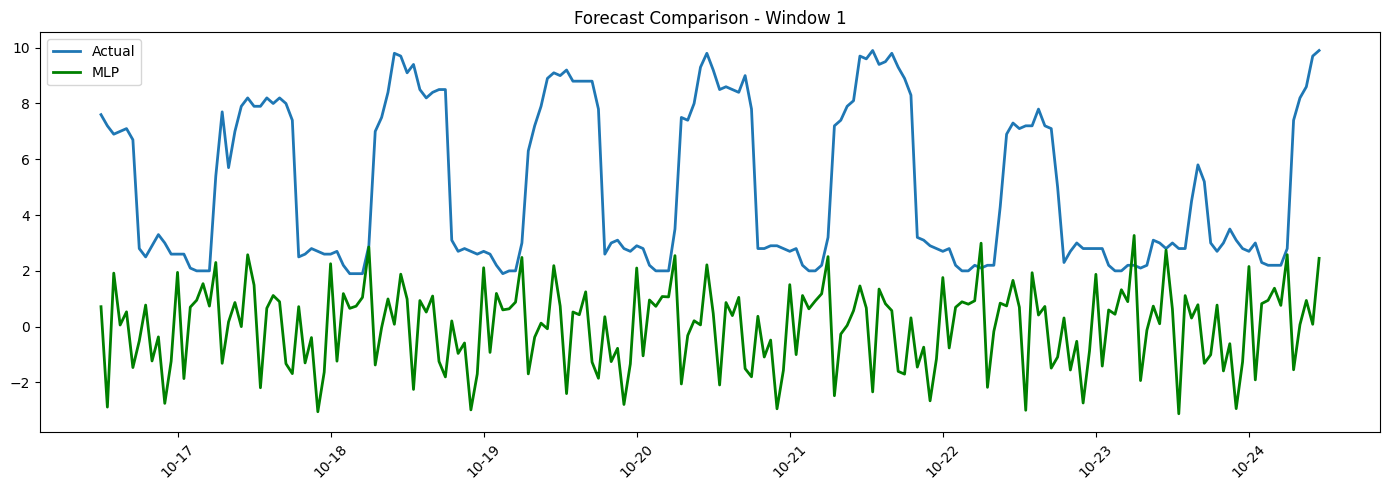

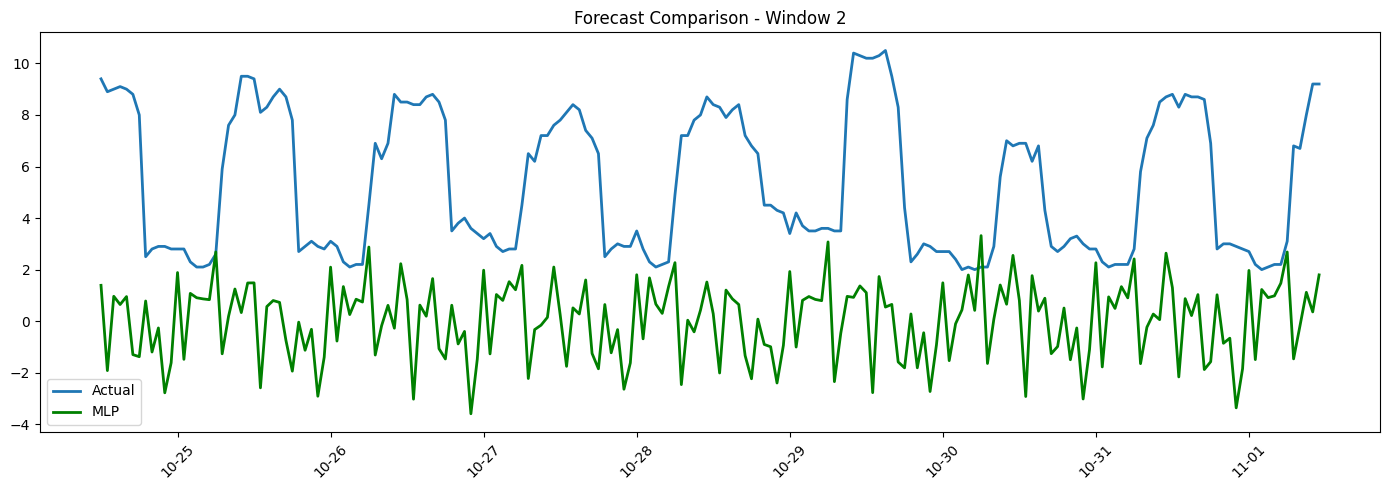

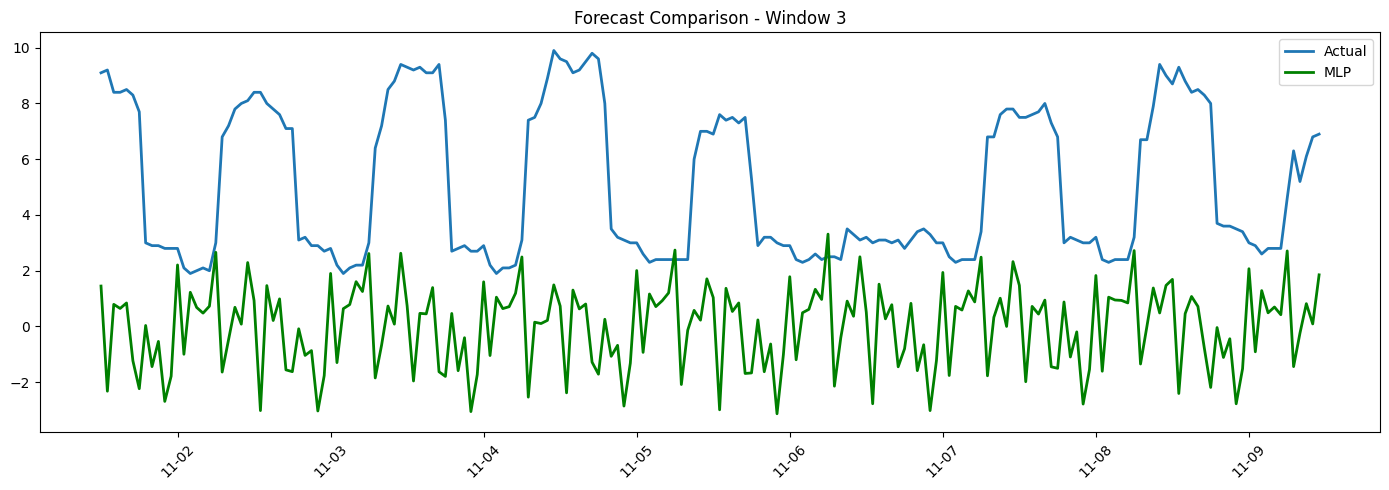

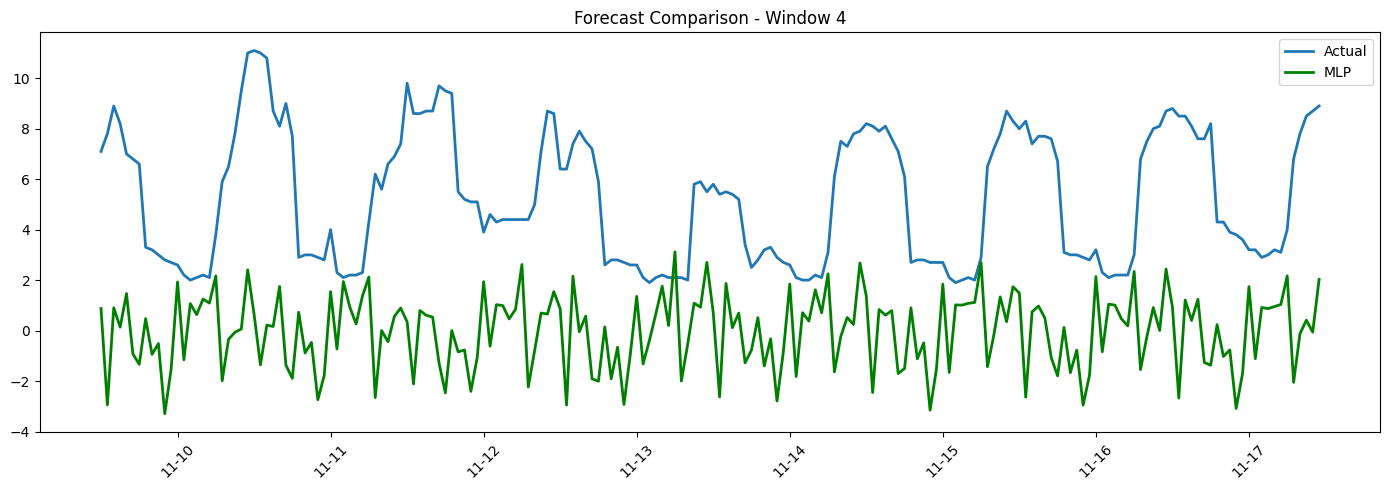

In [16]:

days_per_plot = 8
points_per_plot = days_per_plot * 24

n_plots = 5

for i in range(1, n_plots):

    pred_start = i * points_per_plot
    pred_end = min(
        (i + 1) * points_per_plot,
        len(actual),
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    # Actual
    ax.plot(
        time_index[pred_start:pred_end],
        actual[pred_start:pred_end],
        label="Actual",
        linewidth=2,
    )

    # MLP
    ax.plot(
        time_index[pred_start:pred_end],
        y_pred_unscaled_mlp[pred_start:pred_end],
        label="MLP",
        linewidth=2,
        color="green",
    )

    ax.xaxis.set_major_locator(
        mdates.DayLocator(interval=1)
    )
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%m-%d")
    )

    plt.xticks(rotation=45)
    plt.title(f"Forecast Comparison - Window {i}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## EnergyTTM

#### Loading EnergyTTM (168-24-commercial)
The current variant is pretrained on synthetic commercial data, and is inteded to be used for commercial building data. User may experiment with other variants depending on use case.

In [17]:

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
args = {
    "num_input_channels": 1,
    "context_length": 168,  # 1 week of hourly data
    "prediction_length": 24,   # Forecasting next 24 hours
    "patch_stride": 24,
}


# Initialize Model

ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    "EnergyFM/energy-ttm",  # Name of the model on Hugging Face
    revision="168-24-comm", # model revision: 168-24-res, 512-96-comm, 512-96-res
    num_input_channels=1,  # tsp.num_input_channels 
).to(device)

#### Helper function for pre-processing and evaluation

In [18]:

def standardize_series(series, eps=1e-8):
    mean = np.mean(series)
    std = np.std(series)
    standardized_series = (series - mean) / (std+eps)
    return standardized_series, mean, std

def unscale_predictions(predictions, mean, std, eps=1e-8):
    return predictions * (std+eps) + mean




### Custom Torch Dataset for EnergyTTM

In [19]:

class TimeSeriesDataset(Dataset):
    def __init__(self, data, backcast_length, forecast_length, stride=1):
        # Standardize the time series data
        self.data, self.mean, self.std = standardize_series(data)
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.backcast_length - self.forecast_length) // self.stride + 1

    def __getitem__(self, index):
        start_index = index * self.stride
        x = self.data[start_index : start_index + self.backcast_length]
        y = self.data[start_index + self.backcast_length : start_index + self.backcast_length + self.forecast_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [20]:
def create_dataset_if_valid(energy_data, args):

    # Minimum required length to form at least one training sample
    min_required = args["context_length"] + args["prediction_length"]

    # Skip if series is too short
    if len(energy_data) < min_required:
        print("   Too short, skipping...")
        return None

    # Create dataset using sliding windows
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"]
    )

    # Ensure dataset contains at least one sample
    if len(dataset) == 0:
        print("   No samples, skipping...")
        return None

    return dataset



#### Intialising Train and Test Dataset

In [21]:
test_dataset = create_dataset_if_valid(test["meter_reading"].values, args)  
train_dataset = create_dataset_if_valid(train["meter_reading"].values, args=args)
print("Test size:", len(test_dataset))
print("Train size:", len(train_dataset))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Test size: 84
Train size: 267


### Inferencing on Test dataset

In [22]:

ttm_model.eval()

val_losses = []
y_true_test = []
y_pred_test_ttm = []

# Iterate over dataset one sample at a time
for x_test, y_test in test_loader:

    # Add channel dimension and move to device
    x_test = x_test.unsqueeze(-1).to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        # Forward pass
        output = ttm_model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_test)

        # Skip if loss is NaN
        if torch.isnan(loss):
            continue

        # Store results
        val_losses.append(loss.item())
        y_true_test.append(y_test.cpu().numpy())
        y_pred_test_ttm.append(forecast.cpu().numpy())

# If no valid predictions collected
if len(y_true_test) == 0:
    y_true_test = np.array([])
    y_pred_test_ttm = np.array([])

# Concatenate predictions and ground truth
y_true = np.concatenate(y_true_test, axis=0)
y_pred = np.concatenate(y_pred_test_ttm, axis=0)



In [23]:
mean = test_dataset.mean
std  = test_dataset.std

y_true_flat = y_true.reshape(-1)
y_pred_flat = y_pred.reshape(-1)


y_true_unscaled = unscale_predictions(y_true_flat, mean, std)
y_pred_unscaled_ttm = unscale_predictions(y_pred_flat, mean, std)


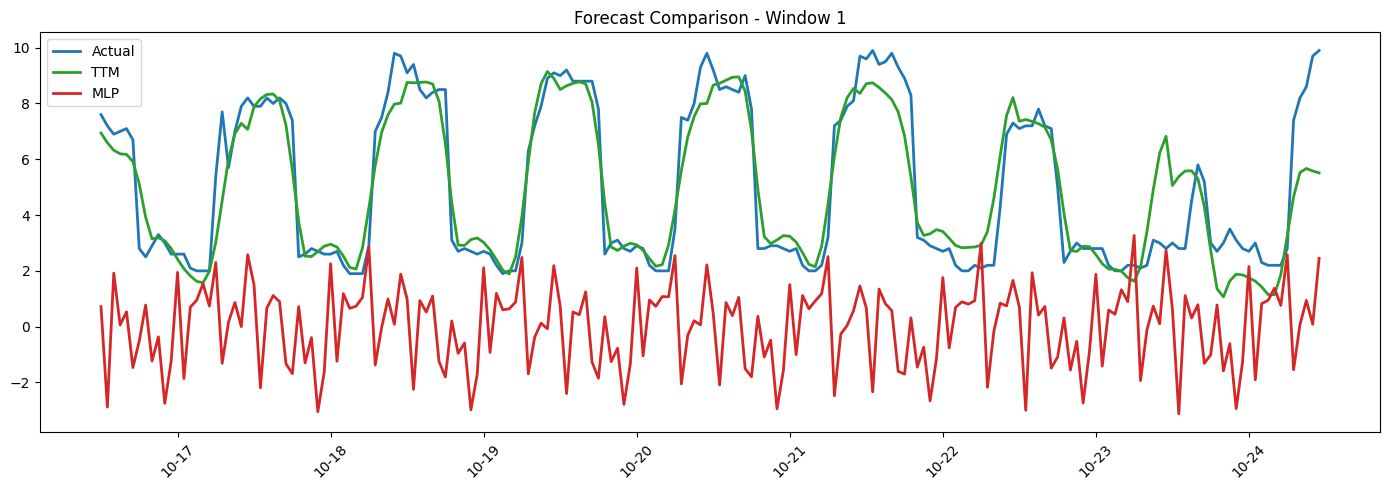

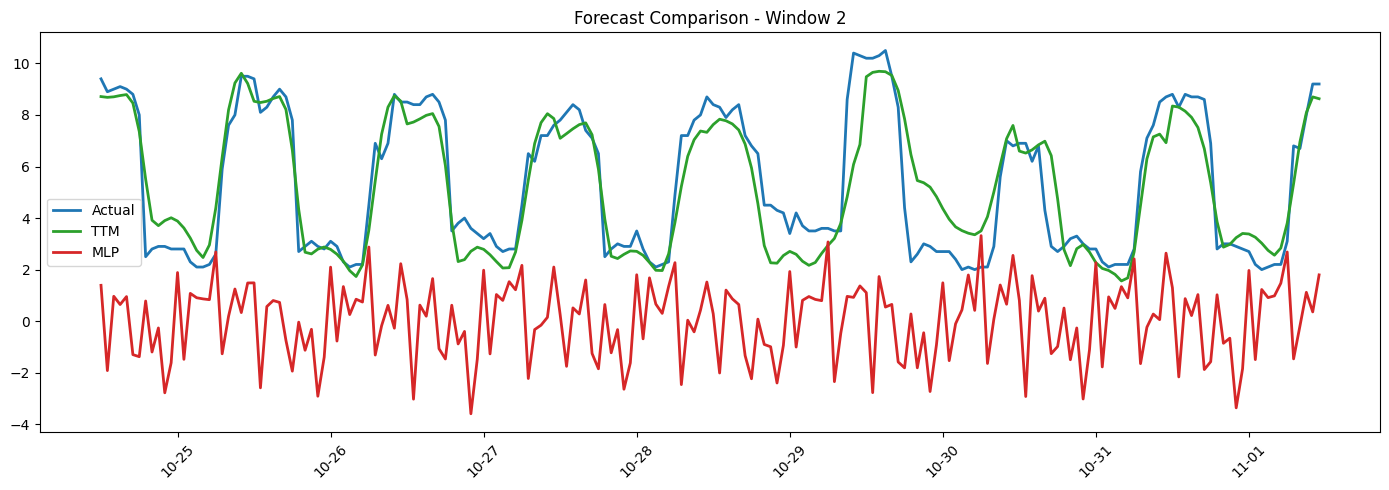

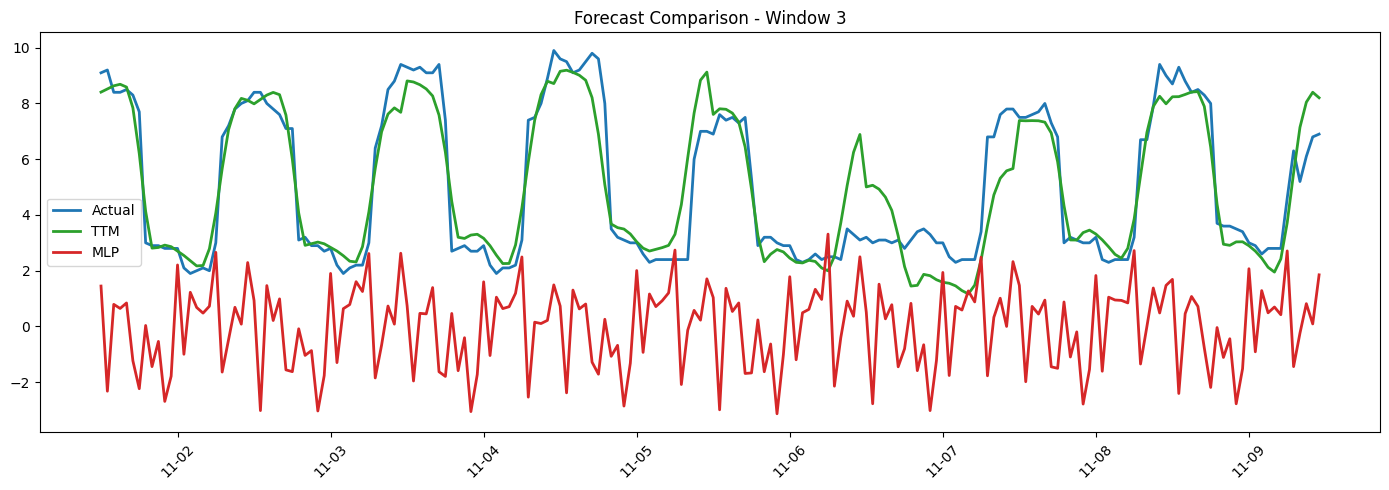

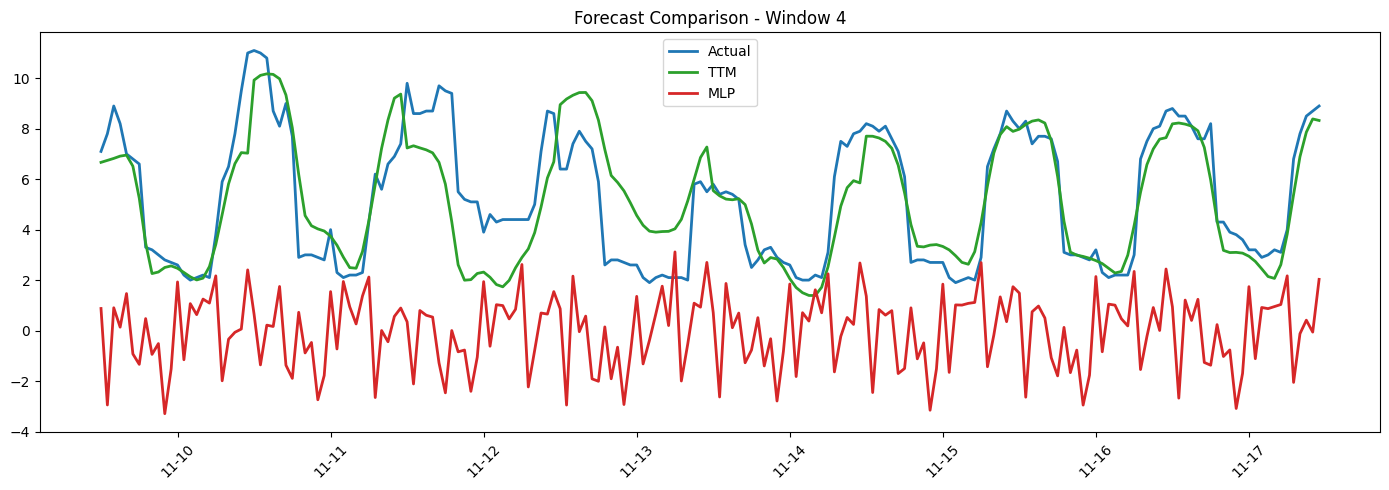

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Predictions correspond to test[168:]

model_time_index = test.index[168:]

actual = test["meter_reading"].iloc[168:].values

ttm_pred = np.asarray(y_pred_unscaled_ttm)
dlinear_pred = np.asarray(y_pred_unscaled_mlp)

# Safety check
min_len = min(
    len(model_time_index),
    len(actual),
    len(ttm_pred),
    len(dlinear_pred),
)

model_time_index = model_time_index[:min_len]
actual = actual[:min_len]
ttm_pred = ttm_pred[:min_len]
dlinear_pred = dlinear_pred[:min_len]

days_per_plot = 8
points_per_plot = days_per_plot * 24

n_plots = 5

for i in range(1, n_plots):

    start = i * points_per_plot
    end = min((i + 1) * points_per_plot, min_len)

    fig, ax = plt.subplots(figsize=(14, 5))

    # Actual
    ax.plot(
        model_time_index[start:end],
        actual[start:end],
        label="Actual",
        linewidth=2,
        color="tab:blue",
    )

    # TTM
    ax.plot(
        model_time_index[start:end],
        ttm_pred[start:end],
        label="TTM",
        linewidth=2,
        color="tab:green",
    )

    # MLP
    ax.plot(
        model_time_index[start:end],
        dlinear_pred[start:end],
        label="MLP",
        linewidth=2,
        color="tab:red",
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    plt.xticks(rotation=45)
    plt.title(f"Forecast Comparison - Window {i}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


common_len = min(
    len(y_true_unscaled.reshape(-1)),
    len(y_pred_unscaled_ttm.reshape(-1)),
    len(y_pred_unscaled_mlp.reshape(-1)),
)

y_true = y_true_unscaled.reshape(-1)[:common_len]
y_pred_ttm = y_pred_unscaled_ttm.reshape(-1)[:common_len]
y_pred_mlp = y_pred_unscaled_mlp    .reshape(-1)[:common_len]

# TTM Metrics

mae_ttm = mean_absolute_error(y_true, y_pred_ttm)
rmse_ttm = np.sqrt(mean_squared_error(y_true, y_pred_ttm))

# MLP Metrics

mae_mlp = mean_absolute_error(y_true, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_true, y_pred_mlp))

print("TTM")
print(f"MAE  : {mae_ttm:.4f}")
print(f"RMSE : {rmse_ttm:.4f}")

print()

print("MLP")
print(f"MAE  : {mae_mlp:.4f}")
print(f"RMSE : {rmse_mlp:.4f}")

TTM
MAE  : 0.9113
RMSE : 1.2316

MLP
MAE  : 5.2004
RMSE : 6.0373
